# 🏠 House Price Prediction using Linear Regression

### Incode Vision Internship — Task 02

This project focuses on building a Linear Regression model to predict house prices using selected property features.

### Objective

To develop a machine learning model that learns the relationship between important house features and their sale prices, evaluates the model using regression metrics, and predicts the price of a new house.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab

## 1. Project Objective

The objective of this project is to:

- Load and explore the house price dataset
- Select relevant features for prediction
- Check for missing values
- Split the dataset into training and testing sets
- Build a Linear Regression model
- Generate house price predictions
- Evaluate model performance using MAE, MSE, and R² Score
- Visualize actual vs predicted prices
- Analyze prediction errors using residuals
- Predict the price of a new house

## 2. Import Libraries
## 3. Load Dataset

## 4. Dataset Overview


In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1460, 81)

First 5 Rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Column Names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'Pool

## 5. Feature Selection


In [15]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]

X = df[features]
y = df["SalePrice"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

display(X.head())
display(y.head())

X Shape: (1460, 6)
y Shape: (1460,)


,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt
0,7,1710,2,856,2,2003
1,6,1262,2,1262,2,1976
2,7,1786,2,920,2,2001
3,7,1717,3,756,1,1915
4,8,2198,3,1145,2,2000


,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000


## 6. Missing Value Check


In [16]:
print("Missing Values:")
print(X.isnull().sum())

Missing Values:
OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
FullBath       0
YearBuilt      0
dtype: int64


## 7. Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1168, 6)
X_test: (292, 6)
y_train: (1168,)
y_test: (292,)



## 8. Build Linear Regression Model
Linear Regression is a supervised machine learning algorithm used to predict a continuous numerical value.

In this project, the model learns the relationship between selected house features and the target variable, SalePrice.

## 9. Model Training

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Coefficients:")
print(model.coef_)

print("\nIntercept:")
print(model.intercept_)

Coefficients:
[20507.20127944    51.99339782 15329.40853924    24.47539959
 -5421.21034048   350.91167193]

Intercept:
-759894.3243911286


## 11. Model Evaluation


In [19]:
y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred[:10])

Predicted Prices:
[143345.09052504 295831.75475447 122206.49630347 177280.62009441
 287975.46943114  56886.42980661 210437.89139038 173697.4206396
  56184.60646274 130980.92806045]



## 10. Prediction

After training the Linear Regression model, predictions are generated using the test dataset.

The model uses the learned relationships between the selected features and house prices to predict the `SalePrice` for unseen houses.


In [20]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(comparison.head(10))

,Actual Price,Predicted Price
0,154500,143345.090525
1,325000,295831.754754
2,115000,122206.496303
3,159000,177280.620094
4,315500,287975.469431
5,75500,56886.429807
6,311500,210437.891390
7,146000,173697.420640
8,84500,56184.606463
9,135500,130980.928060


## 11. Model Evaluation
The trained model is evaluated using three commonly used regression metrics:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted prices.
- **MSE (Mean Squared Error):** Measures the average squared difference between actual and predicted prices and gives more importance to larger errors.
- **R² Score:** Measures how much of the variation in house prices is explained by the model.

Daani kinda mana existing metrics code undali:

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 25319.86044431353
MSE: 1576962754.8842602
R² Score: 0.7944073417103643


## 12. Actual vs Predicted Prices
This visualization compares the actual house prices with the prices predicted by the Linear Regression model.

A diagonal reference line represents perfect predictions. Points closer to this line indicate predictions that are closer to the actual values.

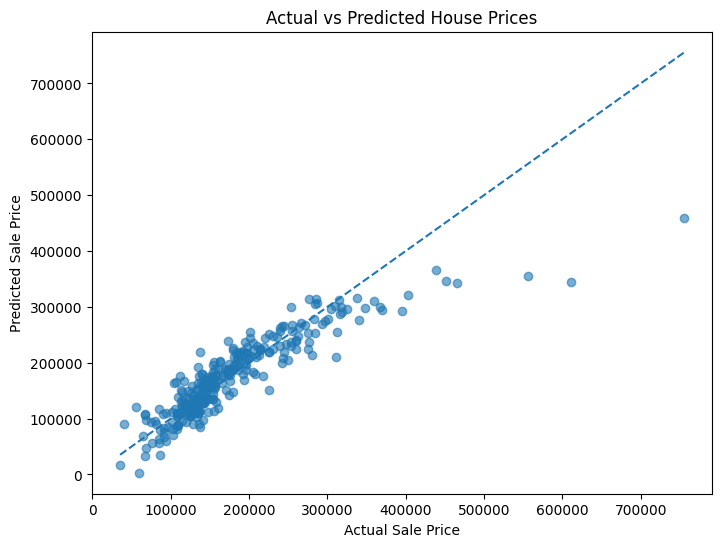

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

13. Residual Analysis
Residual is the difference between the actual price and the predicted price.

Residual = Actual Price − Predicted Price

The residual plot helps us understand how the prediction errors are distributed across the model's predictions.

In [23]:
print("===== Linear Regression Model Summary =====")

print("\nFeatures Used:")
for feature in features:
    print("-", feature)

print("\nIntercept:", model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.2f}")

print("\nModel Performance:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

===== Linear Regression Model Summary =====

Features Used:
- OverallQual
- GrLivArea
- GarageCars
- TotalBsmtSF
- FullBath
- YearBuilt

Intercept: -759894.3243911286

Coefficients:
OverallQual: 20507.20
GrLivArea: 51.99
GarageCars: 15329.41
TotalBsmtSF: 24.48
FullBath: -5421.21
YearBuilt: 350.91

Model Performance:
MAE: 25319.86
MSE: 1576962754.88
R² Score: 0.7944


## 14. New House Price Prediction
After evaluating the model, it can be used to predict the price of a new house based on its features.

The following example provides values for the six features used during model training.

In [24]:
import joblib

joblib.dump(model, "house_price_linear_regression.pkl")

print("Model saved successfully!")

Model saved successfully!


In [25]:
new_house = pd.DataFrame({
    "OverallQual": [8],
    "GrLivArea": [2000],
    "GarageCars": [2],
    "TotalBsmtSF": [1000],
    "FullBath": [2],
    "YearBuilt": [2010]
})

display(new_house)

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt
0,8,2000,2,1000,2,2010


In [26]:
predicted_price = model.predict(new_house)

print("Predicted House Price: ₹", round(predicted_price[0], 2))

Predicted House Price: ₹ 257774.34


## 15. Conclusion

In this project, a Linear Regression model was developed to predict house sale prices using selected property features.

The dataset was divided into training and testing sets, and the model was trained using six important features:

- OverallQual
- GrLivArea
- GarageCars
- TotalBsmtSF
- FullBath
- YearBuilt

The model achieved an MAE of approximately **$25,319.86** and an R² Score of **0.7944** on the test dataset.

The model can also be used to estimate the price of a new house based on its features.

This project helped strengthen practical understanding of:

- Data preparation
- Feature selection
- Train-test splitting
- Linear Regression
- Model prediction
- Regression evaluation metrics
- Data visualization
- Residual analysis

Overall, this project provided practical experience in building and evaluating a machine learning regression model using Python and Scikit-learn.